# Class 06 — Bias, Multiple Testing & P-Hacking
**DSC 215 · Statistical Critical Thinking & Experimental Design · UCSD**

*Based on Ritchie (2020), Science Fictions: Chapter 4*

---

Science has two distinct failure modes covered in this class. **Part 1** covers structural biases — publication pressure, confirmation bias, and underpowered studies — that cause the literature to systematically overstate effects even without deliberate fraud. **Part 2** covers multiple testing and p-hacking: deliberate or accidental misuse of significance testing that inflates false positive rates far beyond the nominal α = 0.05.

**Contents:**
1. [Setup & Imports](#1)
2. [Sample Size and the Standard Error](#2)
3. [Publication Bias — The Funnel Plot](#3)
4. [Confirmation Bias — p-values Under H₀](#4)
5. [Meta-Analysis — Forest Plot](#5)
6. [Multiple Testing — Family-Wise Error Rate](#6)
7. [P-Hacking via Data Dredging](#7)
8. [Multiple Testing Corrections — Bonferroni & BH](#8)
9. [Benford's Law — First-Digit Test](#9)
10. [Last-Digit Analysis](#10)
11. [Summary & Corollaries](#11)

---

<a id='1'></a>
## 1. Setup & Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import os

np.random.seed(42)
os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

BLUE   = '#2563EB'
RED    = '#DC2626'
GREEN  = '#16A34A'
ORANGE = '#D97706'
GRAY   = '#6B7280'
PURPLE = '#7C3AED'

print('Ready.')

Ready.


<a id='2'></a>
## 2. Sample Size and the Standard Error

The **Scottish height example** from the slides: test whether Scottish men are taller than Scottish women on average. The test statistic is the difference of sample means. Its standard error is:

$$\text{SE} = \sigma\sqrt{\frac{2}{n}}$$

As $n$ grows, SE shrinks as $1/\sqrt{n}$ — the null hypothesis (difference = 0) moves further into the tail of the sampling distribution, making the true effect easier to detect. The **sample-size conflict**: cost grows linearly with $n$, precision improves only as $\sqrt{n}$. To cut SE in half you need 4× more data.

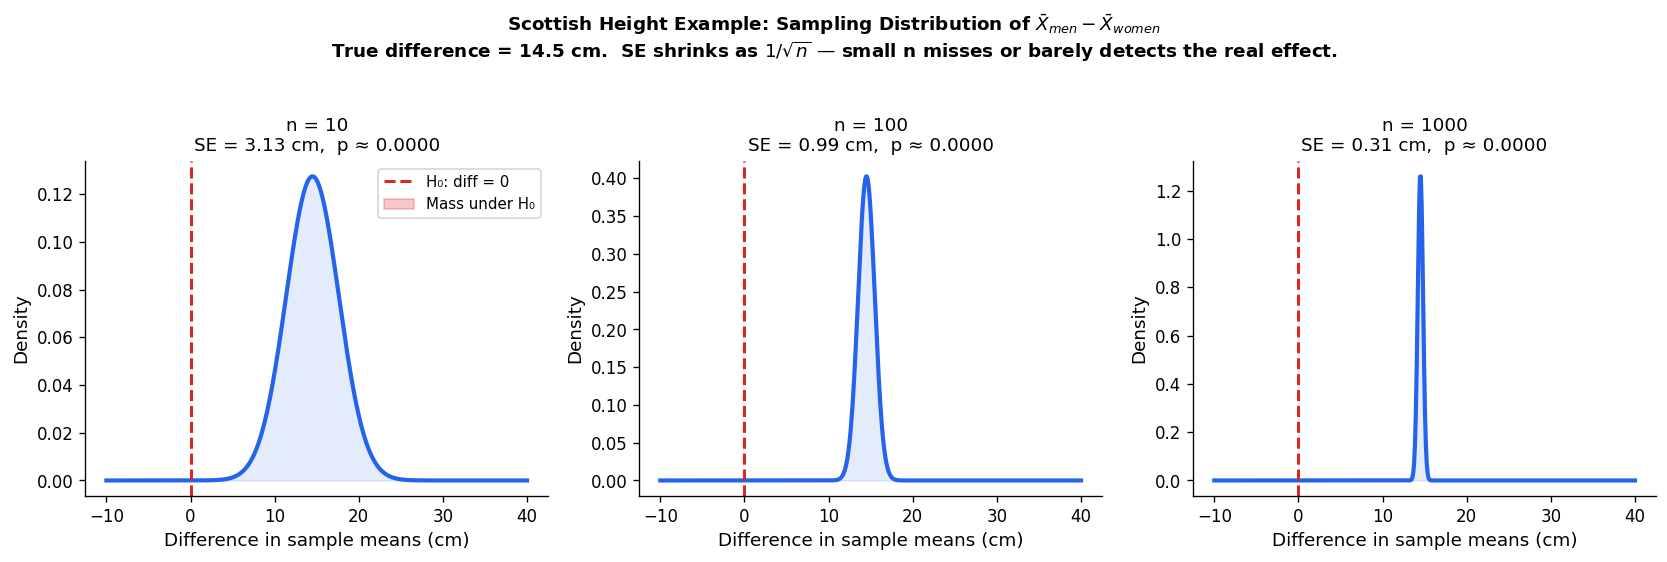

✓ Saved: figures/01_sample_size.png

=== Sample-size conflict ===
       n     SE (cm)       p-value   Cost (relative)
      10       3.130      3.62e-06                 1×
     100       0.990      1.40e-48                10×
    1000       0.313      0.00e+00               100×
   10000       0.099      0.00e+00              1000×

To halve SE: need 4× more data.  To reduce SE by 10×: need 100× more data.


In [3]:
# True population parameters (cm)
mu_men, mu_women = 175.5, 161.0
true_diff = mu_men - mu_women   # 14.5 cm
sigma = 7.0                     # assumed common SD

sample_sizes = [10, 100, 1000]
x = np.linspace(-10, 40, 500)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, n in zip(axes, sample_sizes):
    se  = sigma * np.sqrt(2 / n)
    pdf = stats.norm.pdf(x, loc=true_diff, scale=se)
    t   = true_diff / se
    p   = 2 * stats.norm.sf(abs(t))

    ax.plot(x, pdf, color=BLUE, lw=2.5)
    ax.axvline(0, color=RED, ls='--', lw=1.8, label='H₀: diff = 0')
    ax.fill_between(x, pdf, where=(x < 0),  alpha=0.25, color=RED,  label='Mass under H₀')
    ax.fill_between(x, pdf, where=(x >= 0), alpha=0.12, color=BLUE)
    ax.set_title(f'n = {n}\nSE = {se:.2f} cm,  p ≈ {p:.4f}', fontsize=11)
    ax.set_xlabel('Difference in sample means (cm)')
    ax.set_ylabel('Density')

axes[0].legend(fontsize=9)
plt.suptitle(
    'Scottish Height Example: Sampling Distribution of $\\bar{X}_{men} - \\bar{X}_{women}$\n'
    'True difference = 14.5 cm.  SE shrinks as $1/\\sqrt{n}$ — small n misses or barely detects the real effect.',
    fontsize=11, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/01_sample_size.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/01_sample_size.png')

# Cost-precision trade-off table
print('\n=== Sample-size conflict ===')
print(f'{"n":>8}  {"SE (cm)":>10}  {"p-value":>12}  {"Cost (relative)":>16}')
for n in [10, 100, 1000, 10000]:
    se = sigma * np.sqrt(2 / n)
    p  = 2 * stats.norm.sf(abs(true_diff / se))
    print(f'{n:>8}  {se:>10.3f}  {p:>12.2e}  {n/10:>16.0f}×')
print('\nTo halve SE: need 4× more data.  To reduce SE by 10×: need 100× more data.')

<a id='3'></a>
## 3. Publication Bias — The Funnel Plot

**Publication bias**: journals prefer significant positive findings. Studies with null or small effects stay in the file drawer — their results are never seen. Consequence: the published literature systematically overestimates true effect sizes.

A **funnel plot** diagnoses this. It plots each study's effect size against its precision (1/SE, a proxy for sample size). Under no bias, studies scatter symmetrically inside a funnel around the true effect. When the lower-left region — small studies with small effects — is systematically missing, the funnel becomes asymmetric.

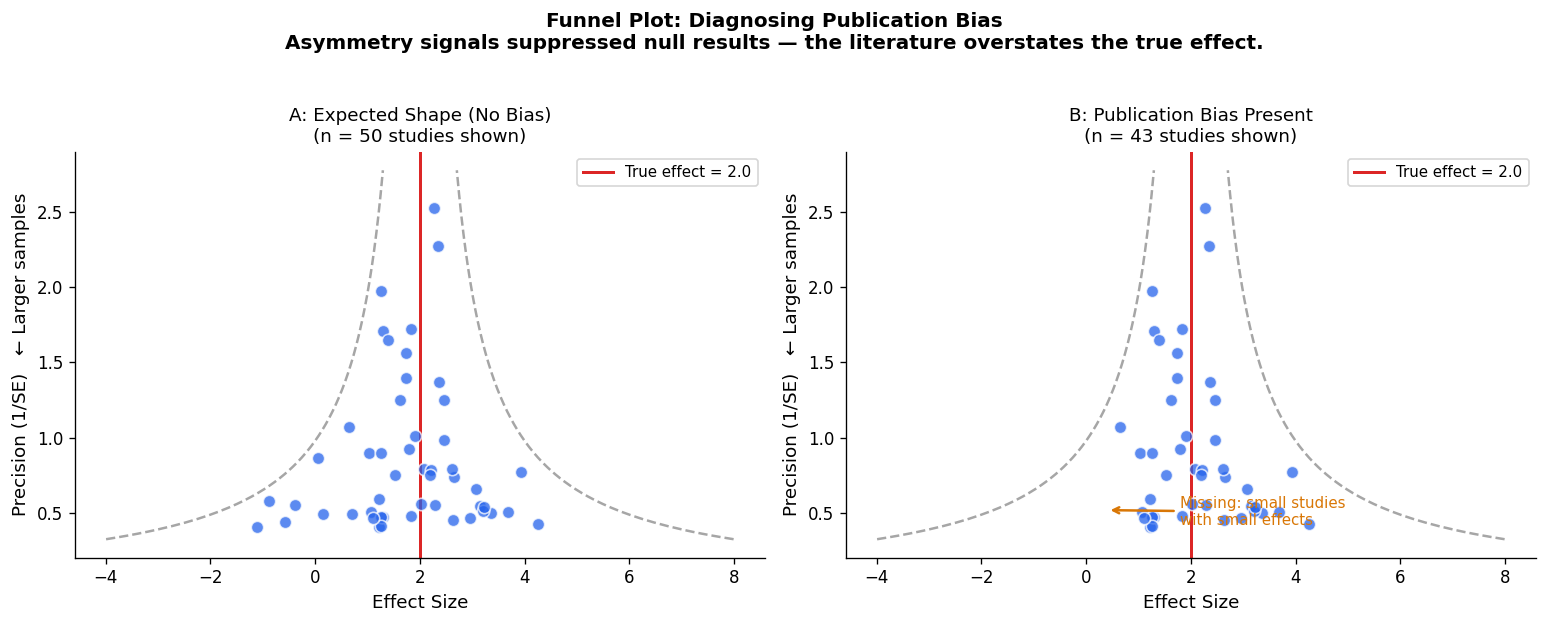

✓ Saved: figures/02_funnel_plot.png
Studies in unbiased plot: 50
Studies remaining after publication bias: 43 (86% retained)


In [4]:
rng = np.random.default_rng(42)
true_effect = 2.0
n_studies   = 50

ses            = rng.uniform(0.3, 2.5, n_studies)
effects_all    = rng.normal(loc=true_effect, scale=ses)

# Publication bias: suppress small-effect studies with large SE
keep           = (effects_all > 0.8) | (ses < 1.0)
effects_biased = effects_all[keep]
ses_biased     = ses[keep]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, effs, se_arr, title, n_shown in [
    (ax1, effects_all,    ses,        'A: Expected Shape (No Bias)',   n_studies),
    (ax2, effects_biased, ses_biased, 'B: Publication Bias Present',   keep.sum()),
]:
    prec = 1 / se_arr
    ax.scatter(effs, prec, color=BLUE, edgecolors='white', s=55, alpha=0.75, zorder=3)

    y_range = np.linspace(prec.min() * 0.8, prec.max() * 1.1, 200)
    ax.plot(true_effect + 1.96 / y_range, y_range, 'k--', alpha=0.35, lw=1.5)
    ax.plot(true_effect - 1.96 / y_range, y_range, 'k--', alpha=0.35, lw=1.5)
    ax.axvline(true_effect, color=RED, lw=1.8, label=f'True effect = {true_effect}')

    if title.startswith('B'):
        ax.annotate(
            'Missing: small studies\nwith small effects',
            xy=(0.4, 0.52), xytext=(1.8, 0.42),
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.5),
            fontsize=9, color=ORANGE
        )

    ax.set_xlabel('Effect Size')
    ax.set_ylabel('Precision (1/SE)   ← Larger samples')
    ax.set_title(f'{title}\n(n = {n_shown} studies shown)', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle(
    'Funnel Plot: Diagnosing Publication Bias\n'
    'Asymmetry signals suppressed null results — the literature overstates the true effect.',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/02_funnel_plot.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/02_funnel_plot.png')
print(f'Studies in unbiased plot: {n_studies}')
print(f'Studies remaining after publication bias: {keep.sum()} ({keep.mean():.0%} retained)')

<a id='4'></a>
## 4. Confirmation Bias — p-values Under H₀

**Confirmation bias** is the tendency to obtain results consistent with prior expectations — through financial incentives (prove the drug works), ego incentives (prove my idea is correct), or unconscious analytic choices.

A critical statistical fact: under H₀, p-values are **Uniform(0,1)**. Exactly 5% fall below 0.05 by chance alone. A researcher who keeps reanalyzing until p < 0.05 exploits this uniformity — generating false positives at will without realizing it.

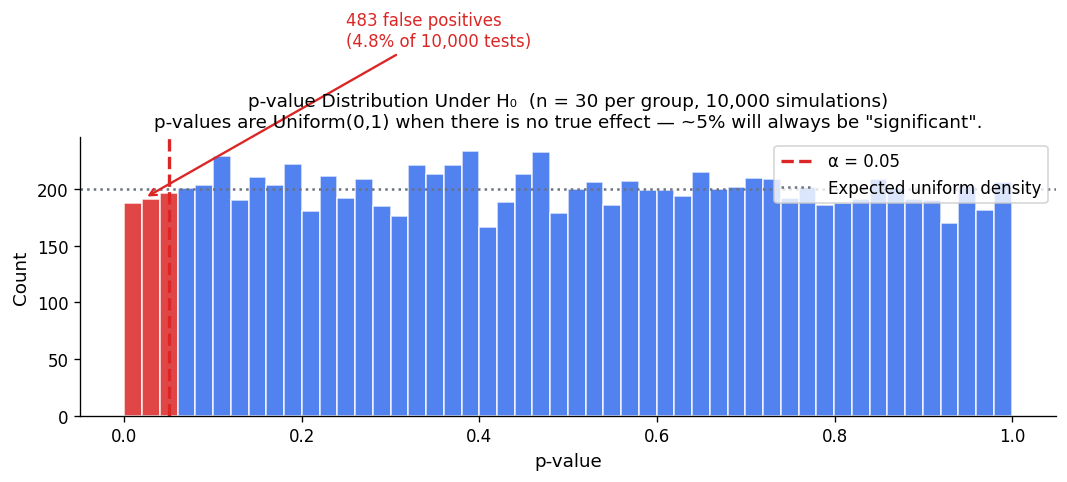

✓ Saved: figures/03_confirmation_bias.png

Observed false positive rate: 483/10000 = 0.048
A researcher who reruns analyses until p < 0.05 exploits this uniform distribution.


In [5]:
rng          = np.random.default_rng(0)
alpha        = 0.05
n_per_group  = 30
n_sims       = 10_000

# Under H0: both groups N(0,1) — no true effect whatsoever
p_values = np.array([
    stats.ttest_ind(
        rng.normal(0, 1, n_per_group),
        rng.normal(0, 1, n_per_group)
    ).pvalue
    for _ in range(n_sims)
])
false_pos = (p_values < alpha).sum()

fig, ax = plt.subplots(figsize=(9, 4.5))
counts, bins, patches = ax.hist(p_values, bins=50, color=BLUE, edgecolor='white', alpha=0.8)

for patch, left in zip(patches, bins[:-1]):
    if left < alpha:
        patch.set_facecolor(RED)
        patch.set_alpha(0.85)

ax.axvline(alpha, color=RED, ls='--', lw=2, label=f'α = {alpha}')
ax.axhline(n_sims / 50, color=GRAY, ls=':', lw=1.5, label='Expected uniform density')
ax.annotate(
    f'{false_pos} false positives\n({false_pos/n_sims:.1%} of {n_sims:,} tests)',
    xy=(alpha * 0.45, counts[:3].mean()),
    xytext=(0.25, counts[:3].mean() * 1.7),
    arrowprops=dict(arrowstyle='->', color=RED, lw=1.4),
    fontsize=10, color=RED
)
ax.set_xlabel('p-value')
ax.set_ylabel('Count')
ax.set_title(
    f'p-value Distribution Under H₀  (n = {n_per_group} per group, {n_sims:,} simulations)\n'
    'p-values are Uniform(0,1) when there is no true effect — ~5% will always be "significant".',
    fontsize=11
)
ax.legend()
plt.tight_layout()
plt.savefig('figures/03_confirmation_bias.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/03_confirmation_bias.png')
print(f'\nObserved false positive rate: {false_pos}/{n_sims} = {false_pos/n_sims:.3f}')
print('A researcher who reruns analyses until p < 0.05 exploits this uniform distribution.')

<a id='5'></a>
## 5. Meta-Analysis — Forest Plot

**Meta-analysis** pools results from multiple independent studies via **inverse-variance weighting**: studies with smaller SE (larger $n$, more precision) get more weight.

$$\hat{\mu}_{\text{pooled}} = \frac{\sum w_i \hat{\mu}_i}{\sum w_i}, \qquad w_i = \frac{1}{\text{SE}_i^2}, \qquad \text{SE}_{\text{pooled}} = \frac{1}{\sqrt{\sum w_i}}$$

The **forest plot** is the standard visualization: one row per study, showing the effect estimate and its 95% CI. A diamond at the bottom shows the pooled estimate. Marker size is proportional to study weight.

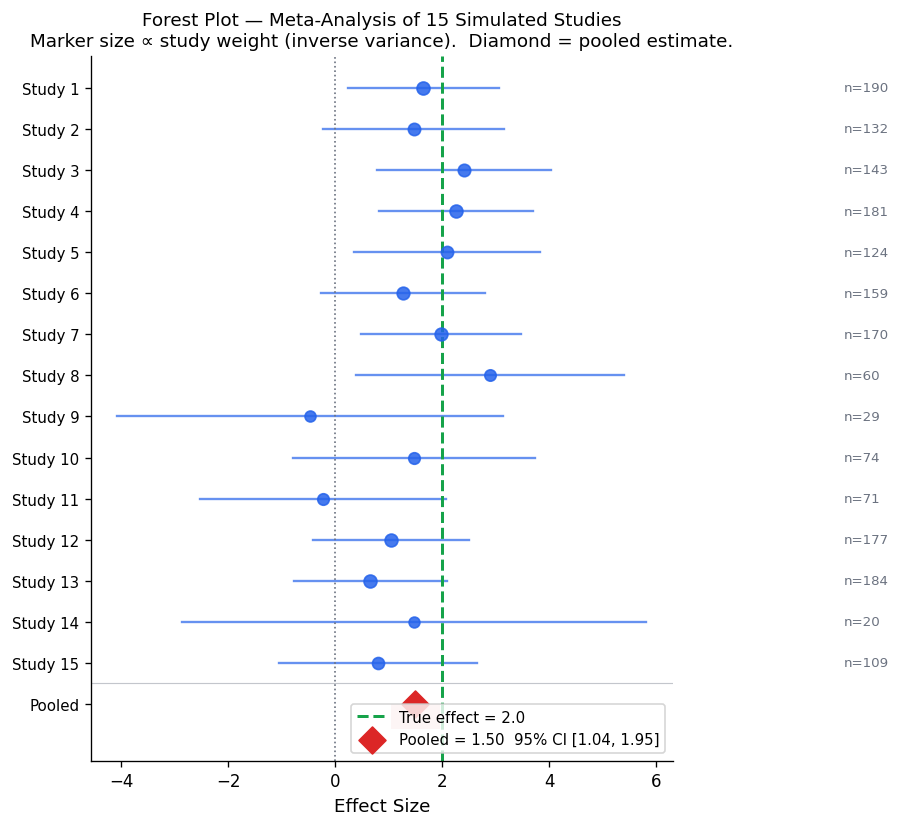

✓ Saved: figures/04_meta_analysis.png
True effect:     2.0
Pooled estimate: 1.498  (SE = 0.232)
95% CI:          [1.044, 1.953]


In [6]:
def pooled_effect(effects, ses):
    """Inverse-variance weighted pooled effect estimate and SE."""
    weights  = 1 / ses**2
    pooled_e = np.average(effects, weights=weights)
    pooled_s = np.sqrt(1 / weights.sum())
    return pooled_e, pooled_s

rng        = np.random.default_rng(7)
true_eff   = 2.0
study_ns   = rng.integers(20, 200, size=15)
study_ses  = 7.0 * np.sqrt(2 / study_ns)
study_effs = rng.normal(loc=true_eff, scale=study_ses)

pool_e, pool_se = pooled_effect(study_effs, study_ses)
pool_lo = pool_e - 1.96 * pool_se
pool_hi = pool_e + 1.96 * pool_se

fig, ax = plt.subplots(figsize=(8, 7))
y_pos = np.arange(len(study_effs), 0, -1)
weights = 1 / study_ses**2
rel_w   = weights / weights.sum()

for y, eff, se, n, w in zip(y_pos, study_effs, study_ses, study_ns, rel_w):
    ci_lo = eff - 1.96 * se
    ci_hi = eff + 1.96 * se
    ax.plot([ci_lo, ci_hi], [y, y], color=BLUE, lw=1.4, alpha=0.7)
    ax.scatter(eff, y, s=40 + 200 * w, color=BLUE, zorder=4, alpha=0.85)
    ax.text(9.5, y, f'n={n}', va='center', fontsize=8, color=GRAY)

# Pooled estimate as diamond
ax.axvline(0,        color=GRAY,  ls=':', lw=1)
ax.axvline(true_eff, color=GREEN, ls='--', lw=1.8, label=f'True effect = {true_eff}')
ax.barh(-0.3, pool_hi - pool_lo, left=pool_lo, height=0.6,
        color=RED, alpha=0.22, zorder=2)
ax.scatter(pool_e, 0, marker='D', s=130, color=RED, zorder=5,
           label=f'Pooled = {pool_e:.2f}  95% CI [{pool_lo:.2f}, {pool_hi:.2f}]')
ax.axhline(0.5, color=GRAY, ls='-', lw=0.7, alpha=0.4)

ax.set_yticks(list(y_pos) + [0])
ax.set_yticklabels([f'Study {i+1}' for i in range(len(study_effs))] + ['Pooled'], fontsize=9)
ax.set_xlabel('Effect Size')
ax.set_title(
    'Forest Plot — Meta-Analysis of 15 Simulated Studies\n'
    'Marker size ∝ study weight (inverse variance).  Diamond = pooled estimate.',
    fontsize=11
)
ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('figures/04_meta_analysis.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/04_meta_analysis.png')
print(f'True effect:     {true_eff}')
print(f'Pooled estimate: {pool_e:.3f}  (SE = {pool_se:.3f})')
print(f'95% CI:          [{pool_lo:.3f}, {pool_hi:.3f}]')

<a id='6'></a>
## 6. Multiple Testing — Family-Wise Error Rate

The **jelly bean problem**: test $m$ independent hypotheses each at level $\alpha$. The **Family-Wise Error Rate (FWER)** — probability of at least one false positive — is:

$$\text{FWER} = 1 - (1-\alpha)^m$$

The expected number of false positives is $m \times \alpha$. Testing 20 jelly bean colors at α = 0.05: FWER ≈ 64%, and we expect exactly 1 false positive even if none cause acne. Finding green beans "significant" and reporting it as a discovery is exactly this error in action.

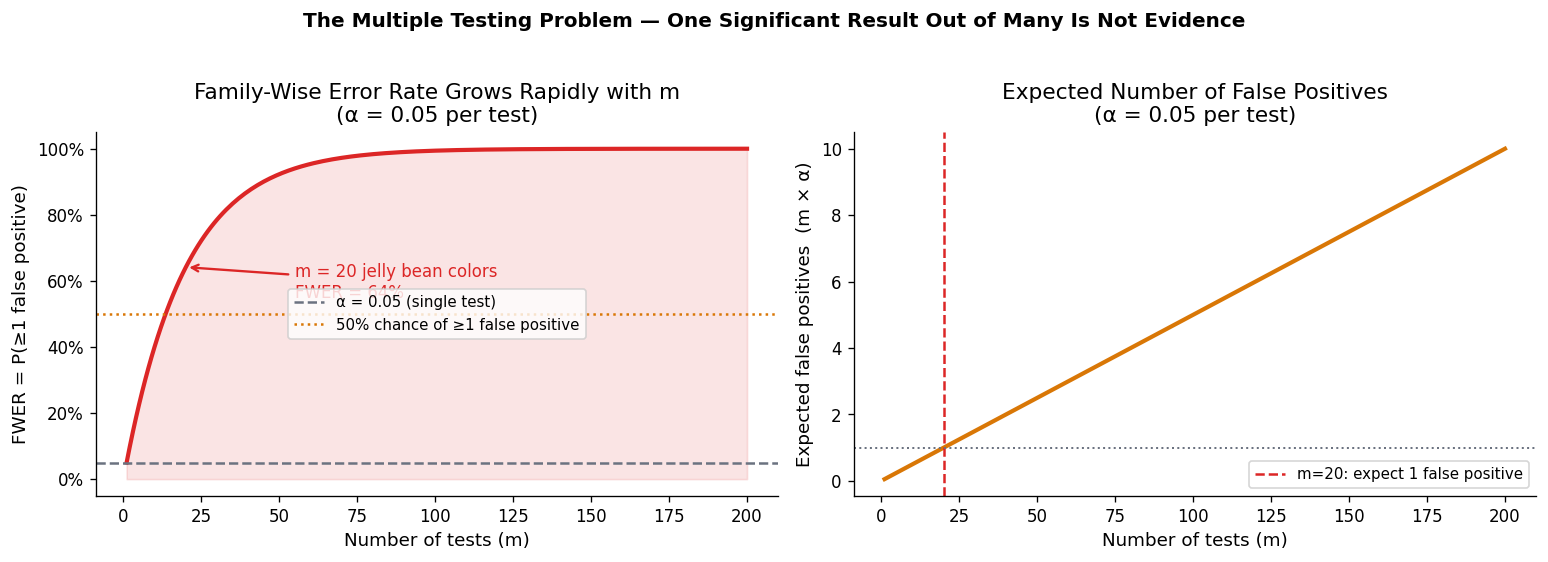

✓ Saved: figures/05_fwer.png

Jelly bean scenario (m=20, α=0.05):
  FWER                     = 64.2%
  Expected false positives = 1.0


In [7]:
alpha    = 0.05
m_values = np.arange(1, 201)
fwer     = 1 - (1 - alpha) ** m_values

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: FWER vs number of tests
ax = axes[0]
ax.plot(m_values, fwer, color=RED, lw=2.5)
ax.fill_between(m_values, fwer, alpha=0.12, color=RED)
ax.axhline(0.05, color=GRAY,   ls='--', lw=1.5, label='α = 0.05 (single test)')
ax.axhline(0.50, color=ORANGE, ls=':',  lw=1.5, label='50% chance of ≥1 false positive')

m_jelly    = 20
fwer_jelly = 1 - (1 - alpha) ** m_jelly
ax.annotate(
    f'm = 20 jelly bean colors\nFWER = {fwer_jelly:.0%}',
    xy=(m_jelly, fwer_jelly), xytext=(55, 0.55),
    arrowprops=dict(arrowstyle='->', color=RED, lw=1.4),
    fontsize=10, color=RED
)
ax.set_xlabel('Number of tests (m)')
ax.set_ylabel('FWER = P(≥1 false positive)')
ax.set_title('Family-Wise Error Rate Grows Rapidly with m\n(α = 0.05 per test)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=9)

# Right: expected false positives vs m
ax2 = axes[1]
ax2.plot(m_values, m_values * alpha, color=ORANGE, lw=2.5)
ax2.axvline(m_jelly, color=RED, ls='--', lw=1.5,
            label=f'm=20: expect {m_jelly*alpha:.0f} false positive')
ax2.axhline(1, color=GRAY, ls=':', lw=1.2)
ax2.set_xlabel('Number of tests (m)')
ax2.set_ylabel('Expected false positives  (m × α)')
ax2.set_title('Expected Number of False Positives\n(α = 0.05 per test)')
ax2.legend(fontsize=9)

plt.suptitle(
    'The Multiple Testing Problem — One Significant Result Out of Many Is Not Evidence',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/05_fwer.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/05_fwer.png')
print(f'\nJelly bean scenario (m=20, α=0.05):')
print(f'  FWER                     = {fwer_jelly:.1%}')
print(f'  Expected false positives = {m_jelly * alpha:.1f}')

<a id='7'></a>
## 7. P-Hacking via Data Dredging

**P-hacking** is manipulating analysis choices — selectively removing outliers, adding/removing covariates, stopping data collection when p just crosses 0.05, or searching large datasets — until a significant result appears.

**Data dredging** is a systematic form: given a large dataset, test many candidate predictors and report only those that reach significance. Below: 30 predictors, all independent of the outcome under H₀. Every significant result is a false positive. Note also the **winner's curse**: significant results have inflated |r| compared to their true value of 0.

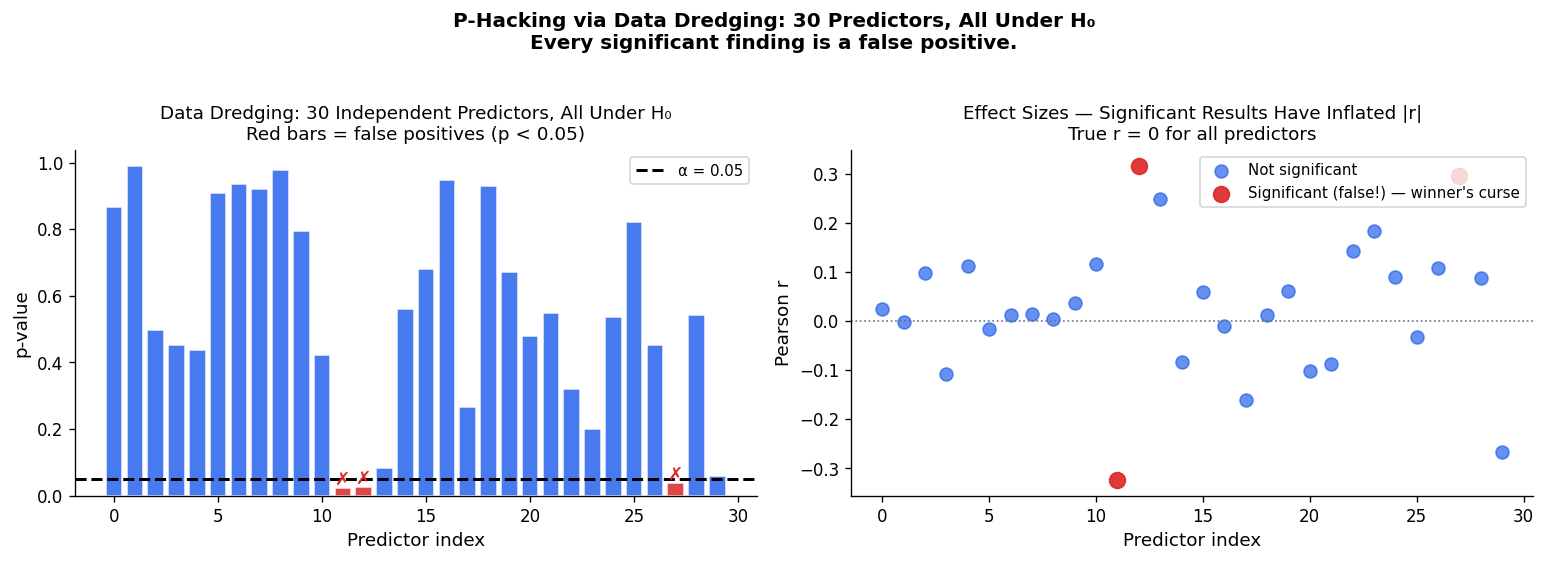

✓ Saved: figures/06_phacking.png

Significant findings: 3 / 30  (expected ≈ 2)
Every single one is a false positive.


In [8]:
rng    = np.random.default_rng(7)
n      = 50
n_vars = 30
alpha  = 0.05

outcome    = rng.normal(size=n)
predictors = rng.normal(size=(n, n_vars))

p_vals = np.array([stats.pearsonr(outcome, predictors[:, j]).pvalue    for j in range(n_vars)])
r_vals = np.array([stats.pearsonr(outcome, predictors[:, j]).statistic for j in range(n_vars)])
sig    = p_vals < alpha

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: p-value bar chart
ax = axes[0]
bar_colors = [RED if s else BLUE for s in sig]
ax.bar(range(n_vars), p_vals, color=bar_colors, edgecolor='white', alpha=0.85)
ax.axhline(alpha, color='black', ls='--', lw=1.8, label=f'α = {alpha}')
for i in np.where(sig)[0]:
    ax.text(i, p_vals[i] + 0.01, '✗', ha='center', color=RED, fontsize=11, fontweight='bold')
ax.set_xlabel('Predictor index')
ax.set_ylabel('p-value')
ax.set_title(
    f'Data Dredging: {n_vars} Independent Predictors, All Under H₀\n'
    f'Red bars = false positives (p < {alpha})', fontsize=11
)
ax.legend(fontsize=9)

# Right: winner's curse — significant results have inflated |r|
ax2 = axes[1]
ax2.scatter(np.where(~sig)[0], r_vals[~sig], color=BLUE, s=60, alpha=0.7, label='Not significant')
ax2.scatter(np.where(sig)[0],  r_vals[sig],  color=RED,  s=90, alpha=0.9,
            label="Significant (false!) — winner's curse", zorder=4)
ax2.axhline(0, color=GRAY, ls=':', lw=1)
ax2.set_xlabel('Predictor index')
ax2.set_ylabel('Pearson r')
ax2.set_title("Effect Sizes — Significant Results Have Inflated |r|\nTrue r = 0 for all predictors", fontsize=11)
ax2.legend(fontsize=9)

plt.suptitle(
    "P-Hacking via Data Dredging: 30 Predictors, All Under H₀\n"
    'Every significant finding is a false positive.',
    fontsize=12, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/06_phacking.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/06_phacking.png')
print(f'\nSignificant findings: {sig.sum()} / {n_vars}  (expected ≈ {n_vars * alpha:.0f})')
print('Every single one is a false positive.')

<a id='8'></a>
## 8. Multiple Testing Corrections — Bonferroni & BH

Two standard corrections:

| Method | Rule | Controls |
|--------|------|----------|
| **Bonferroni** | Reject if $p_i < \alpha/m$ | FWER — at most one false positive on average |
| **Benjamini-Hochberg (BH)** | Rank $p$-values; reject if $p_{(i)} \leq \frac{i}{m}\alpha$ | FDR — controlled proportion of false positives among rejections |

Bonferroni is conservative. BH is more powerful when many tests are run and some true effects exist. Both are applied to the p-values from Section 7.

=== Multiple Testing Corrections (p-values from Section 7) ===
  Uncorrected  (p < 0.05):       3 significant
  Bonferroni corrected:           0 significant
  Benjamini-Hochberg (FDR):       0 significant
  Bonferroni threshold:         α/m = 0.05/30 = 0.0017


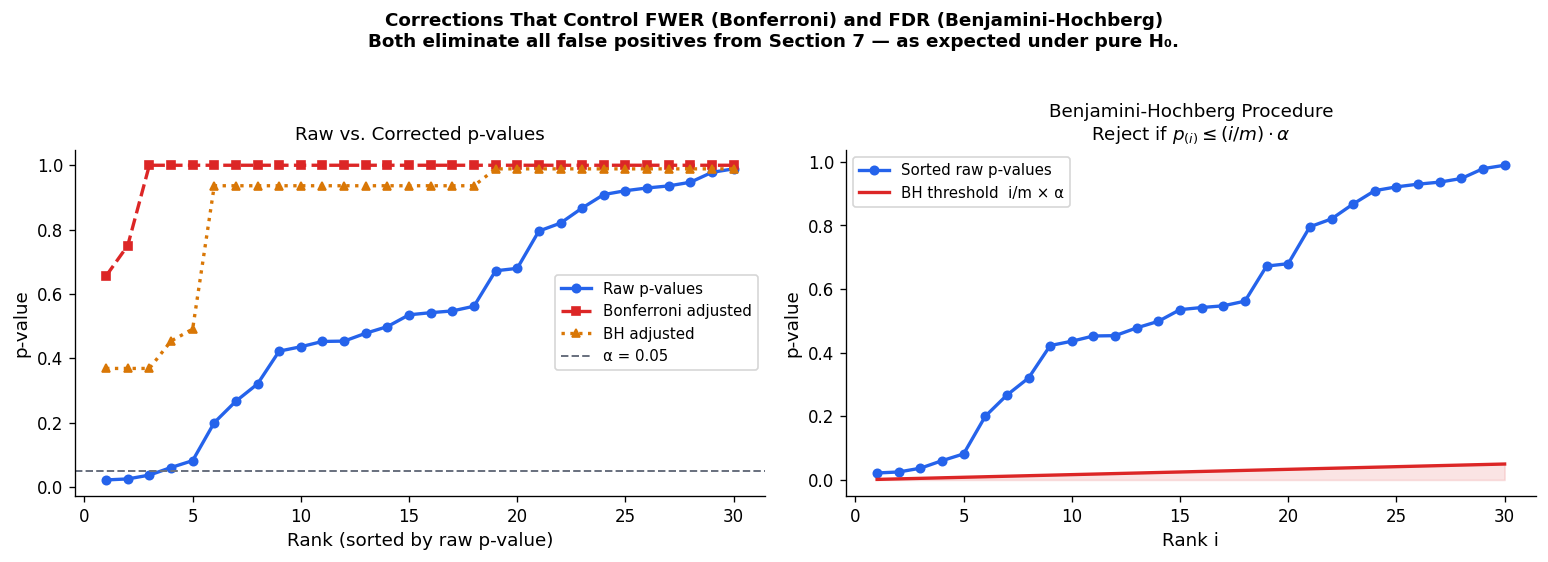

✓ Saved: figures/07_corrections.png


In [9]:
from statsmodels.stats.multitest import multipletests

bonf_reject, bonf_p, _, _ = multipletests(p_vals, alpha=0.05, method='bonferroni')
bh_reject,   bh_p,   _, _ = multipletests(p_vals, alpha=0.05, method='fdr_bh')

print('=== Multiple Testing Corrections (p-values from Section 7) ===')
print(f'  Uncorrected  (p < 0.05):     {sig.sum():>3} significant')
print(f'  Bonferroni corrected:         {bonf_reject.sum():>3} significant')
print(f'  Benjamini-Hochberg (FDR):     {bh_reject.sum():>3} significant')
print(f'  Bonferroni threshold:         α/m = 0.05/{n_vars} = {0.05/n_vars:.4f}')

sort_idx = np.argsort(p_vals)
ranks    = np.arange(1, n_vars + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: raw vs adjusted p-values
ax = axes[0]
ax.plot(ranks, p_vals[sort_idx],   'o-',  color=BLUE,   lw=2, ms=5, label='Raw p-values')
ax.plot(ranks, bonf_p[sort_idx],  's--',  color=RED,    lw=2, ms=5, label='Bonferroni adjusted')
ax.plot(ranks, bh_p[sort_idx],    '^:',   color=ORANGE, lw=2, ms=5, label='BH adjusted')
ax.axhline(0.05, color=GRAY, ls='--', lw=1.2, label='α = 0.05')
ax.set_xlabel('Rank (sorted by raw p-value)')
ax.set_ylabel('p-value')
ax.set_title('Raw vs. Corrected p-values', fontsize=11)
ax.legend(fontsize=9)

# Right: BH procedure visualized
ax2 = axes[1]
bh_threshold = ranks / n_vars * 0.05
ax2.plot(ranks, p_vals[sort_idx], 'o-', color=BLUE, lw=2, ms=5, label='Sorted raw p-values')
ax2.plot(ranks, bh_threshold,     '-',  color=RED,  lw=2,       label='BH threshold  i/m × α')
ax2.fill_between(ranks, bh_threshold, alpha=0.12, color=RED)
ax2.set_xlabel('Rank i')
ax2.set_ylabel('p-value')
ax2.set_title('Benjamini-Hochberg Procedure\nReject if $p_{(i)} \\leq (i/m) \\cdot \\alpha$', fontsize=11)
ax2.legend(fontsize=9)

plt.suptitle(
    'Corrections That Control FWER (Bonferroni) and FDR (Benjamini-Hochberg)\n'
    'Both eliminate all false positives from Section 7 — as expected under pure H₀.',
    fontsize=11, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/07_corrections.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/07_corrections.png')

<a id='9'></a>
## 9. Benford's Law — First-Digit Test

In many naturally occurring datasets spanning several orders of magnitude, the leading digit $d$ follows **Benford's Law**:

$$P(d) = \log_{10}\!\left(1 + \frac{1}{d}\right), \quad d \in \{1, \ldots, 9\}$$

Digit 1 appears ~30% of the time; digit 9 only ~5%. Scale-invariant — holds regardless of units. Applies to addresses, populations, prices, financial transactions. **Does NOT apply to** Gaussian data or data in a narrow range.

**Historical use:** Proposed by Hal Varian for fraud detection. Applied correctly to the **2009 Iranian elections**. Misapplied to the **2020 US elections** — precinct vote counts are in a narrow range and do not follow Benford's Law.

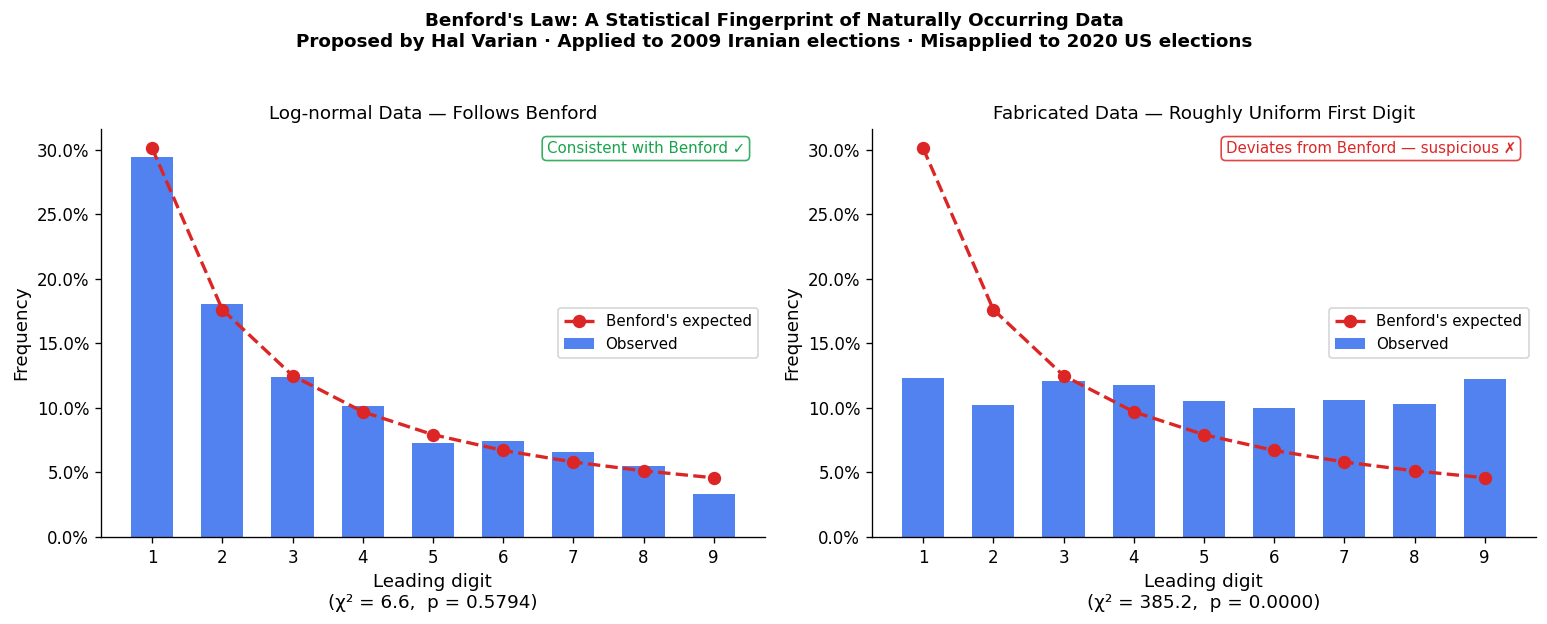

✓ Saved: figures/08_benford.png

Benford's Law expected probabilities:
  Digit 1: 30.1%
  Digit 2: 17.6%
  Digit 3: 12.5%
  Digit 4: 9.7%
  Digit 5: 7.9%
  Digit 6: 6.7%
  Digit 7: 5.8%
  Digit 8: 5.1%
  Digit 9: 4.6%


In [10]:
def first_digit(x):
    """Extract the leading digit of a positive integer."""
    return int(str(abs(int(x)))[0])

digits  = np.arange(1, 10)
benford = np.log10(1 + 1 / digits)

rng = np.random.default_rng(42)

# Real data: log-normal — spans many orders of magnitude
real_data  = rng.lognormal(mean=np.log(1e6), sigma=2.5, size=1000).astype(int)
real_data  = real_data[real_data > 0]
freq_real  = np.array([(np.array([first_digit(x) for x in real_data]) == d).mean() for d in digits])

# Fabricated data: someone generating numbers with roughly uniform first digits
fab_data   = rng.integers(10_000, 100_000_000, size=1000)
freq_fab   = np.array([(np.array([first_digit(x) for x in fab_data]) == d).mean() for d in digits])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, freq, n, title in [
    (axes[0], freq_real, len(real_data), 'Log-normal Data — Follows Benford'),
    (axes[1], freq_fab,  len(fab_data),  'Fabricated Data — Roughly Uniform First Digit'),
]:
    obs = (freq * n).round().astype(int)
    exp = benford * obs.sum()
    chi2, p = stats.chisquare(obs, f_exp=exp)

    ax.bar(digits, freq,    color=BLUE, alpha=0.8, label='Observed', width=0.6)
    ax.plot(digits, benford, 'o--', color=RED, lw=2, ms=7, label="Benford's expected")

    ax.set_xticks(digits)
    ax.set_xlabel(f'Leading digit\n(χ² = {chi2:.1f},  p = {p:.4f})')
    ax.set_ylabel('Frequency')
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=9)

    verdict    = 'Consistent with Benford ✓' if p > 0.05 else 'Deviates from Benford — suspicious ✗'
    box_color  = GREEN if p > 0.05 else RED
    ax.text(0.97, 0.97, verdict,
            transform=ax.transAxes, ha='right', va='top', fontsize=9, color=box_color,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=box_color, alpha=0.85))

plt.suptitle(
    "Benford's Law: A Statistical Fingerprint of Naturally Occurring Data\n"
    'Proposed by Hal Varian · Applied to 2009 Iranian elections · Misapplied to 2020 US elections',
    fontsize=11, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/08_benford.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/08_benford.png')
print("\nBenford's Law expected probabilities:")
for d, pb in zip(digits, benford):
    print(f'  Digit {d}: {pb:.1%}')

<a id='10'></a>
## 10. Last-Digit Analysis

In genuine precise measurements, **last digits should be uniformly distributed** across 0–9. When researchers round or fabricate data (e.g., rounding population figures to the nearest thousand), trailing zeros become over-represented — a directly testable signature.

The slides show this for country populations: the last-digit chi-squared statistic is **105.7**, far above the critical value. About **29.7%** of reported populations end in 0, vs. the expected 10%. This reflects official rounding, not fabrication per se — but the same test catches fabrication.

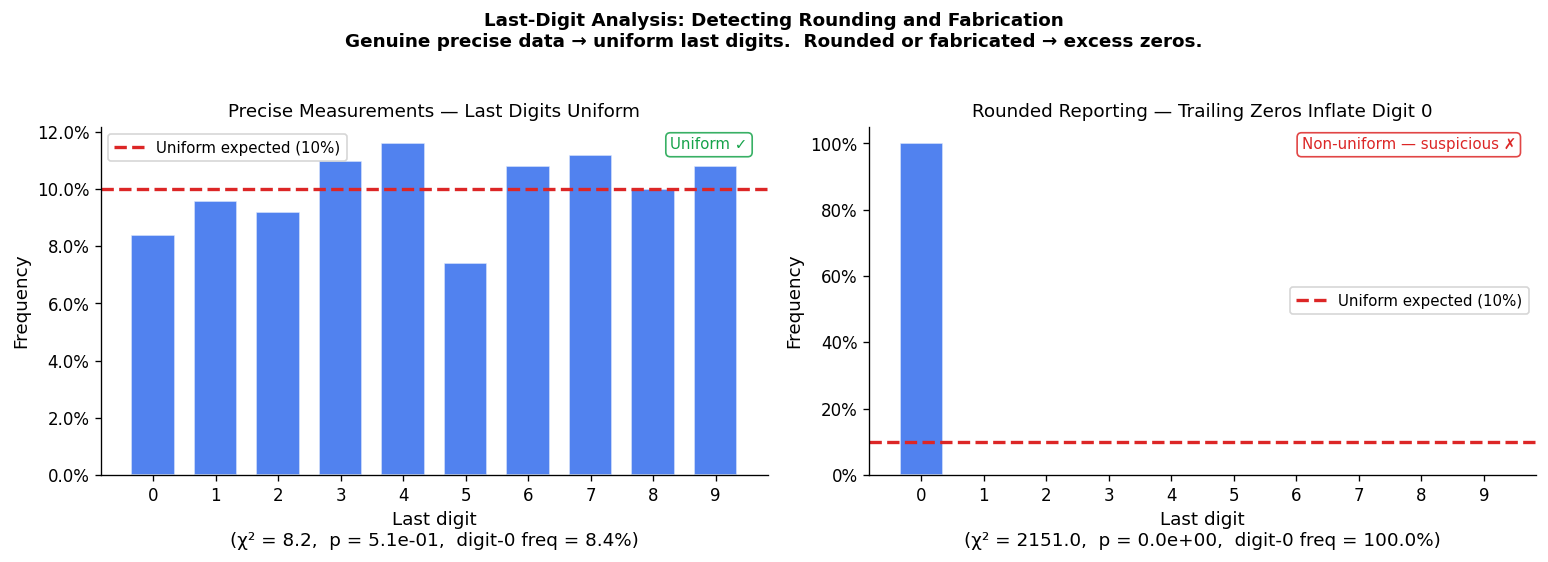

✓ Saved: figures/09_last_digit.png


In [11]:
rng = np.random.default_rng(99)
last_digits = np.arange(10)

# Genuine precise data: last digits should be uniform
genuine     = (rng.lognormal(mean=12, sigma=2, size=500) * 1000).astype(int)
last_genuine = genuine % 10

# Rounded data: values rounded to nearest 1000 — last digit always 0
rounded      = (rng.lognormal(mean=12, sigma=2, size=239) / 1000).astype(int) * 1000
last_rounded = rounded % 10

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, data, title in [
    (axes[0], last_genuine, 'Precise Measurements — Last Digits Uniform'),
    (axes[1], last_rounded, 'Rounded Reporting — Trailing Zeros Inflate Digit 0'),
]:
    counts = np.array([(data == d).sum() for d in last_digits])
    freq   = counts / counts.sum()
    chi2, p = stats.chisquare(counts)

    ax.bar(last_digits, freq, color=BLUE, alpha=0.8, edgecolor='white', width=0.7)
    ax.axhline(0.10, color=RED, ls='--', lw=2, label='Uniform expected (10%)')
    ax.set_xticks(last_digits)
    ax.set_xlabel(f'Last digit\n(χ² = {chi2:.1f},  p = {p:.1e},  digit-0 freq = {freq[0]:.1%})')
    ax.set_ylabel('Frequency')
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=9)

    verdict   = 'Uniform ✓' if p > 0.05 else 'Non-uniform — suspicious ✗'
    box_color = GREEN if p > 0.05 else RED
    ax.text(0.97, 0.97, verdict,
            transform=ax.transAxes, ha='right', va='top', fontsize=9, color=box_color,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=box_color, alpha=0.85))

plt.suptitle(
    'Last-Digit Analysis: Detecting Rounding and Fabrication\n'
    'Genuine precise data → uniform last digits.  Rounded or fabricated → excess zeros.',
    fontsize=11, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.savefig('figures/09_last_digit.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/09_last_digit.png')

<a id='11'></a>
## 11. Summary & Corollaries

All key failure modes from the slides follow directly from the same underlying logic: when the rate of false positives is not controlled — whether through underpowered studies, publication bias, multiple testing, or deliberate manipulation — the published literature cannot be trusted at face value.

In [13]:
corollaries = pd.DataFrame([
    {
        'Part': 'Bias',
        'Concept': 'Sample size & SE',
        'Mechanism': 'SE ∝ 1/√n — underpowered studies miss real effects',
        'Consequence': "Missed effects; inflated effect estimates for what is found (winner's curse)",
        'Remedy': 'Power analysis before data collection'
    },
    {
        'Part': 'Bias',
        'Concept': 'Publication bias',
        'Mechanism': 'Null results suppressed; positive results published',
        'Consequence': 'Literature systematically overestimates true effect sizes',
        'Remedy': 'Pre-registration; registered reports; funnel plot check'
    },
    {
        'Part': 'Bias',
        'Concept': 'Confirmation bias',
        'Mechanism': 'Analytic choices guided by desired outcome',
        'Consequence': 'Inflated false positive rate even without explicit fraud',
        'Remedy': 'Blind analysis; pre-specified analysis plan'
    },
    {
        'Part': 'Bias',
        'Concept': 'Meta-analysis',
        'Mechanism': 'Inverse-variance pooling across independent studies',
        'Consequence': 'Corrects noise; reveals true effect and publication bias',
        'Remedy': 'Inspect funnel plot; use BH-corrected meta-analytic p-values'
    },
    {
        'Part': 'Multiple Testing',
        'Concept': 'FWER inflation',
        'Mechanism': 'FWER = 1−(1−α)^m → 1 as m grows',
        'Consequence': 'One significant result out of many is not evidence',
        'Remedy': 'Bonferroni; pre-specify which tests matter'
    },
    {
        'Part': 'Multiple Testing',
        'Concept': 'P-hacking / Data dredging',
        'Mechanism': 'Search space of analyses until p < 0.05',
        'Consequence': 'All significant results may be false positives',
        'Remedy': 'Bonferroni / BH correction; pre-registration'
    },
    {
        'Part': 'Multiple Testing',
        'Concept': 'P-HARKing',
        'Mechanism': 'Hypothesis formed post-hoc; presented as prior',
        'Consequence': 'Undetectable fraud; exploratory fishing presented as confirmatory',
        'Remedy': 'Pre-registration; distinguish exploratory from confirmatory'
    },
    {
        'Part': 'Data Fabrication',
        'Concept': "Benford's Law",
        'Mechanism': 'First digits of natural data follow log₁₀(1+1/d)',
        'Consequence': 'Fabricated data deviates significantly from Benford',
        'Remedy': 'Chi-squared test on first digits; flag for investigation'
    },
    {
        'Part': 'Data Fabrication',
        'Concept': 'Last-digit test',
        'Mechanism': 'Last digits of precise data are uniform across 0–9',
        'Consequence': 'Excess zeros reveal rounding or fabrication',
        'Remedy': 'Chi-squared test on last digits'
    },
])

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 200)
corollaries.set_index(['Part', 'Concept'])

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 200)
corollaries.set_index(['Part', 'Concept'])

Mechanism                                                  Consequence  \
Part             Concept                                                                                                                                       
Bias             Sample size & SE            SE ∝ 1/√n — underpowered studies miss real effects  Missed effects; inflated effect estimates for what is fo...   
                 Publication bias           Null results suppressed; positive results published    Literature systematically overestimates true effect sizes   
                 Confirmation bias                   Analytic choices guided by desired outcome     Inflated false positive rate even without explicit fraud   
                 Meta-analysis              Inverse-variance pooling across independent studies     Corrects noise; reveals true effect and publication bias   
Multiple Testing FWER inflation                                 FWER = 1−(1−α)^m → 1 as m grows           One significant result out of many is not evidence   
                 P-hacking / Data dredging              Search space of analyses until p < 0.05               All significant results may be false positives   
                 P-HARKing                       Hypothesis formed post-hoc; presented as prior  Undetectable fraud; exploratory fishing presented as con...   
Data Fabrication Benford's Law                 First digits of natural data follow log₁₀(1+1/d)          Fabricated data deviates significantly from Benford   
                 Last-digit test             Last digits of precise data are uniform across 0–9                  Excess zeros reveal rounding or fabrication   

                                                                                                 Remedy  
Part             Concept                                                                                 
Bias             Sample size & SE                                 Power analysis before data collection  
                 Publication bias               Pre-registration; registered reports; funnel plot check  
                 Confirmation bias                          Blind analysis; pre-specified analysis plan  
                 Meta-analysis              Inspect funnel plot; use BH-corrected meta-analytic p-va...  
Multiple Testing FWER inflation                              Bonferroni; pre-specify which tests matter  
                 P-hacking / Data dredging                 Bonferroni / BH correction; pre-registration  
                 P-HARKing                  Pre-registration; distinguish exploratory from confirmatory  
Data Fabrication Benford's Law                 Chi-squared test on first digits; flag for investigation  
                 Last-digit test                                        Chi-squared test on last digits

---

## 📝 Key Takeaways

| Concept | What to Remember |
|---------|------------------|
| **Sample size & SE** | SE shrinks as $1/\sqrt{n}$ — cost grows linearly, precision sublinearly |
| **Publication bias** | Null results stay in the file drawer → literature overstates effect sizes |
| **Confirmation bias** | Analytic flexibility lets researchers find what they expect, even honestly |
| **Meta-analysis** | Inverse-variance pooling; forest plot shows studies + pooled estimate |
| **FWER** | $1-(1-\alpha)^m \to 1$ rapidly — testing 20 things expects 1 false positive |
| **P-hacking** | Dredging 30 predictors at α=0.05 expects 1–2 false positives by design |
| **P-HARKing** | Always fraud — exploratory fishing presented as confirmatory science |
| **Bonferroni / BH** | Bonferroni controls FWER (strict); BH controls FDR (more powerful) |
| **Benford's Law** | First digits follow $\log_{10}(1+1/d)$ — deviations flag fabricated data |
| **Last-digit test** | Precise data → uniform last digits; rounding/fabrication → excess zeros |

---

## 📚 References

- Ritchie, S. (2020). *Science Fictions: How Fraud, Bias, Negligence, and Hype Undermine the Search for Truth.* Metropolitan Books. Chapter 4.
- Simmons, J.P., Nelson, L.D., & Simonsohn, U. (2011). *False-positive psychology: Undisclosed flexibility in data collection and analysis allows presenting anything as significant.* Psychological Science 22(11): 1359–1366.
- Varian, H.R. (1972). *Benford's Law.* The American Statistician 26(3): 65–66.
- Benjamini, Y. & Hochberg, Y. (1995). *Controlling the false discovery rate: a practical and powerful approach to multiple testing.* Journal of the Royal Statistical Society B 57(1): 289–300.

---
*DSC 215 · UCSD · Spring 2026 · Prof. Armin Schwartzman*